In [1]:
import sys

sys.path.append('..')
from pathlib import Path
import numpy as np
from pyedflib import highlevel
import matplotlib.pyplot as plt
from config.constants import SAMPLING_FREQUENCY_HZ

In [2]:
# load EEG
root = Path('/data/home/webb/UNEEG/datasets/ultra2/U002-DE01-01/edf_data')
edf_path = sorted(root.iterdir())[3]
print(edf_path)
signals, sig_headers, header = highlevel.read_edf(str(edf_path))

n_channels, n_samples = signals.shape

to_show = 0.002

sig_starts = signals[:, : int(n_samples * to_show) + 1]
sig_ends = signals[:, int(n_samples * (1 - to_show)):]
# print(sig_starts.shape, sig_ends.shape)
# sigs_se = signals
sigs_se = np.concat([sig_starts, sig_ends], axis=-1)
# sigs_se.shape

/data/home/webb/UNEEG/datasets/ultra2/U002-DE01-01/edf_data/U002-DE01-01_0003_2021-05-15_08-37-52.edf


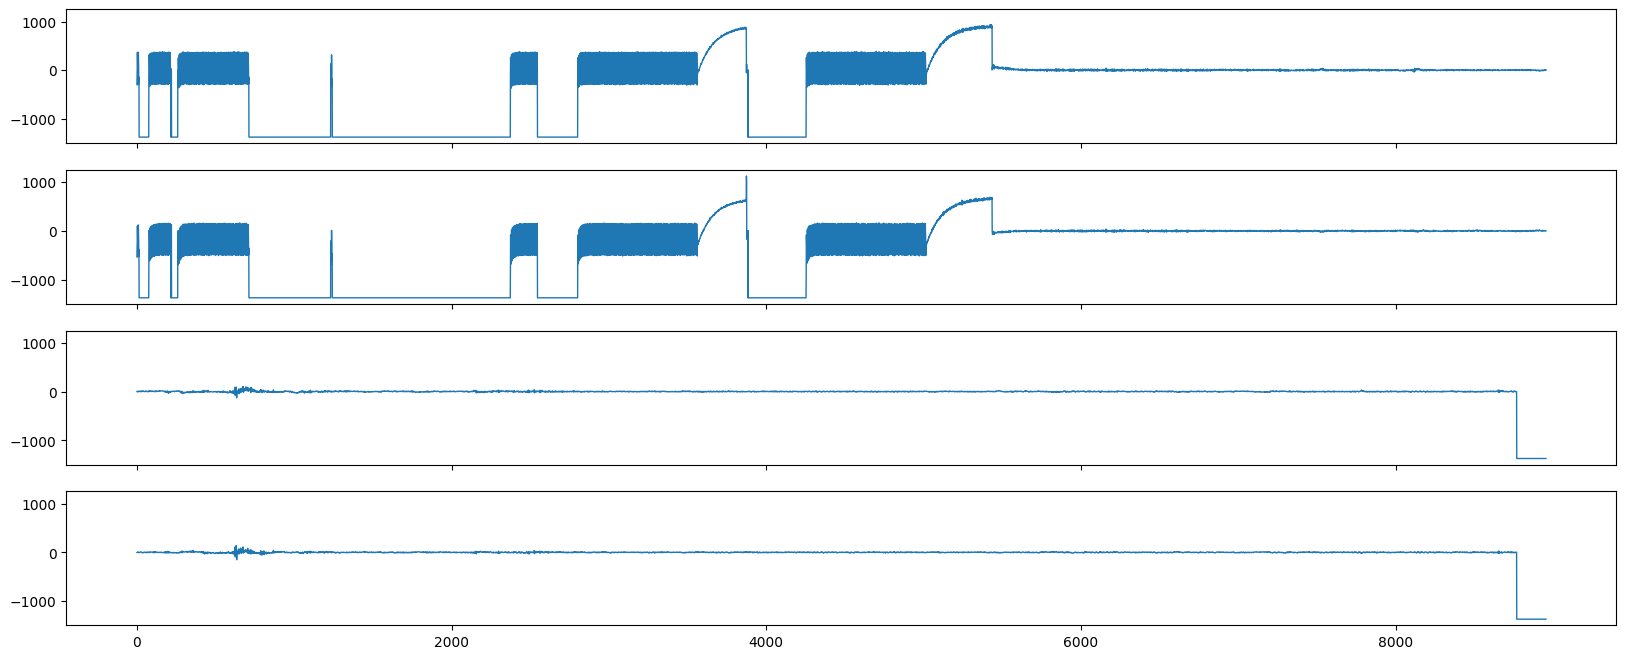

In [11]:
# Plot EEG
sigs_list = [sig_starts, sig_ends]
# sigs_list = [signals]

fig, ax = plt.subplots(nrows=len(sigs_list) * n_channels, sharex=True, sharey=True, figsize=(20, 8))
for sig_i, sig in enumerate(sigs_list):
    for chn in range(n_channels):
        ax[sig_i * len(sigs_list) + chn].plot(sig[chn], linewidth=1)

fig.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def plot_signal_with_bad_regions(
        y: np.ndarray,
        valid_mask: np.ndarray = None,
        valid_intervals: np.ndarray = None,
        x: np.ndarray | None = None,
        ax: plt.Axes | None = None,
        signal_kwargs: dict | None = None,
        bad_color: str = "red",
        bad_alpha: float = 0.20,
) -> plt.Axes:
    """
    Plot a 1D signal and shade regions where good_mask is False (bad) in red.

    Parameters
    ----------
    y : np.ndarray
        1D signal of length N.
    valid_mask : np.ndarray
        Boolean array of length N, True=good, False=bad.
    x : np.ndarray | None
        Optional x-axis values of length N (e.g., time). If None, uses sample indices.
    ax : matplotlib.axes.Axes | None
        Optional axes to plot on. If None, creates a new figure/axes.
    signal_kwargs : dict | None
        Optional kwargs passed to ax.plot for the signal line.
    bad_color : str
        Color used for shading bad regions.
    bad_alpha : float
        Alpha for shading bad regions.

    Returns
    -------
    matplotlib.axes.Axes
        The axes with the plot.
    """
    if x is None:
        x = np.arange(len(y))
    else:
        if x.shape[0] != y.shape[0]:
            raise ValueError(f"x and y must have same length, got {len(x)} and {len(y)}")

    if ax is None:
        _, ax = plt.subplots(figsize=(20, 4))

    if signal_kwargs is None:
        signal_kwargs = {"color": "black", "linewidth": 0.8}

    ax.plot(x, y, **signal_kwargs)

    def shade_intervals(valid_ivs_):
        for s_, e_ in valid_ivs_:
            ax.axvspan(x[s_], x[e_ - 1], color=bad_color, alpha=bad_alpha, linewidth=0)

    if valid_mask is not None:
        if y.shape[0] != valid_mask.shape[0]:
            raise ValueError(f"y and good_mask must have same length, got {len(y)} and {len(valid_mask)}")
        bad = ~valid_mask
        if bad.any():
            # Find contiguous True segments in `bad` and shade them
            edges = np.diff(bad.astype(np.int8))
            starts = np.where(edges == 1)[0] + 1
            ends = np.where(edges == -1)[0] + 1
            if bad[0]:
                starts = np.r_[0, starts]
            if bad[-1]:
                ends = np.r_[ends, bad.size]

            shade_intervals(zip(starts, ends))
    if valid_intervals is not None:
        shade_intervals(valid_intervals)

    ax.set_xlim(x[0], x[-1])
    return ax

<Axes: >

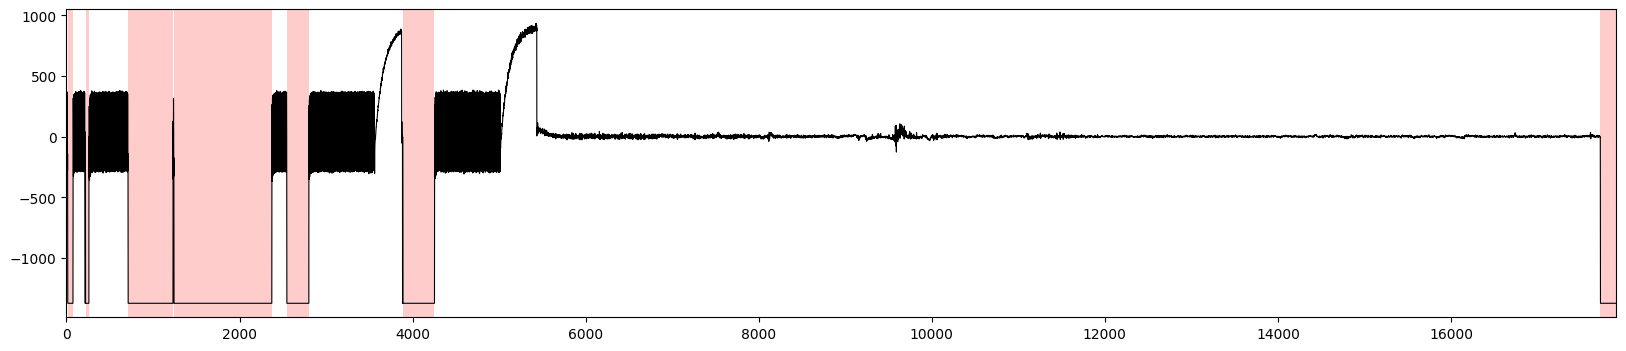

In [6]:
# Filter clipping
minimum, maximum = sig_headers[0]["physical_min"], sig_headers[0]["physical_max"]
atol = 0.1

clipped_per_channel_mask = np.isclose(sigs_se, minimum, atol=atol) | np.isclose(sigs_se, maximum, atol=atol)

chn = 0
plot_signal_with_bad_regions(sigs_se[chn], ~clipped_per_channel_mask[chn])

In [7]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view


def high_variance_mask(signals: np.ndarray, sfreq: float, window_sec=2.0, step_sec=0.5, var_threshold=20_000):
    """
    Returns a boolean mask of shape (n_samples)

    True  = high-variance artifact (any channel has high variance in a window covering that sample)
    False = variance looks normal
    """
    n_ch, n_samples = signals.shape
    win = max(1, int(round(window_sec * sfreq)))
    step = max(1, int(round(step_sec * sfreq)))

    if win > n_samples:
        return np.zeros(n_samples, dtype=bool)

    # Regular windows (only those that fully fit)
    windows = sliding_window_view(signals, win, axis=1)[:, ::step, :]  # (n_ch, n_windows, win)
    var = np.var(windows, axis=-1)  # (n_ch, n_windows)
    bad_windows = (var > var_threshold).any(axis=0)  # (n_windows,)

    starts = np.arange(0, n_samples - win + 1, step)  # (n_windows,)

    # Build per-sample mask by "painting" bad windows
    marks = np.zeros(n_samples, dtype=np.int32)
    if bad_windows.any():
        marks[starts[bad_windows]] = 1

    # Also consider the trailing region by forcing the last full window (ending at n_samples)
    tail_start = n_samples - win
    if starts.size == 0 or starts[-1] != tail_start:
        tail_var = np.var(signals[:, tail_start:tail_start + win], axis=-1)  # (n_ch,)
        tail_bad = bool((tail_var > var_threshold).any())
        if tail_bad:
            marks[tail_start] = 1

    coverage = np.convolve(marks, np.ones(win, dtype=np.int32), mode="full")[:n_samples]
    return coverage > 0


<Axes: >

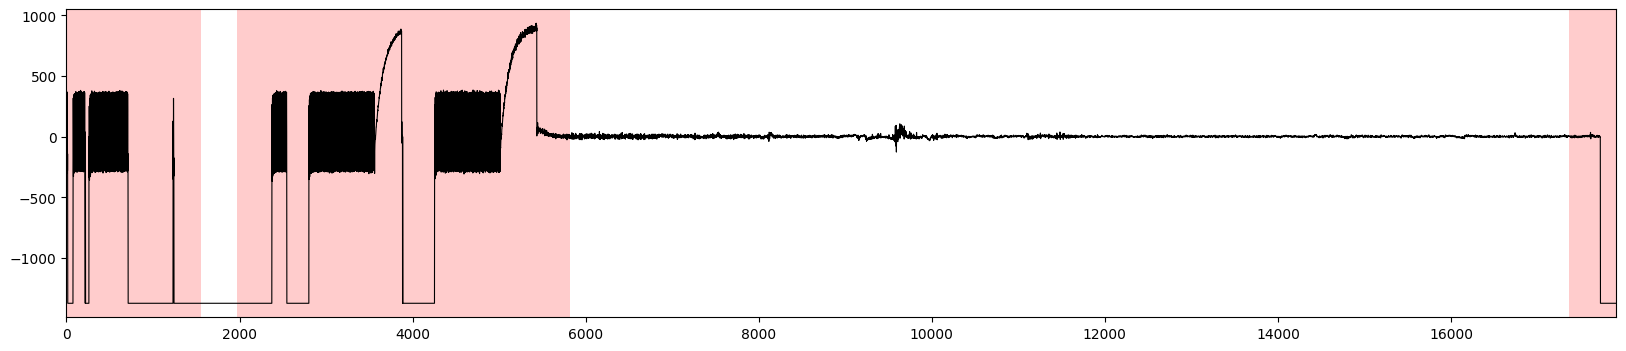

In [8]:
s = sigs_se
high_var_mask = high_variance_mask(s, SAMPLING_FREQUENCY_HZ)
plot_signal_with_bad_regions(s[chn], ~high_var_mask)

(<Axes: xlabel='x', ylabel='signal'>, <Axes: ylabel='variance'>)

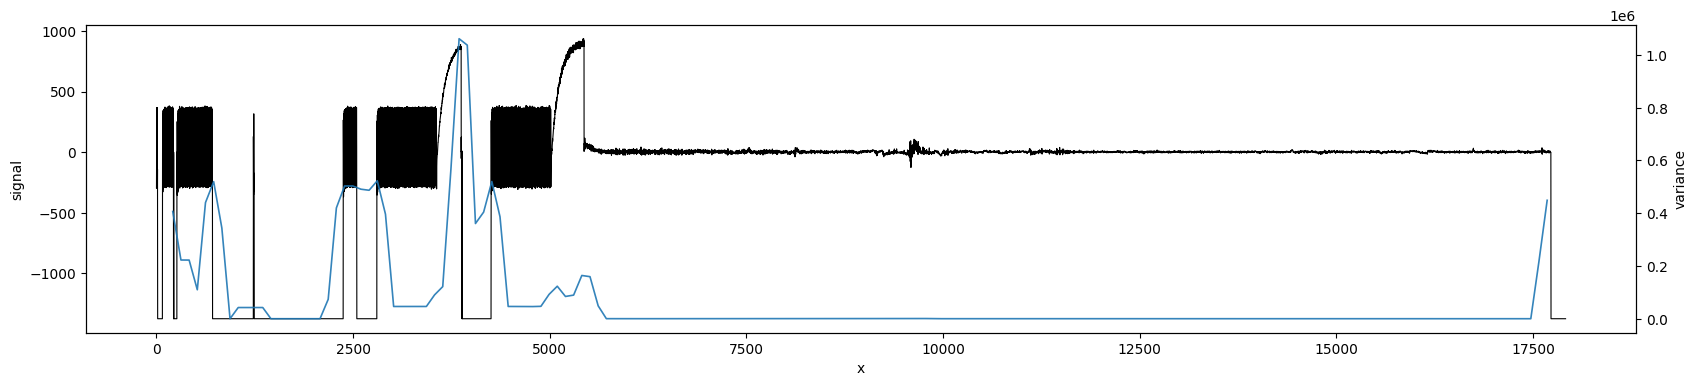

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def plot_signal_with_variance(
        y: np.ndarray,
        *,
        sfreq: float,
        window_sec: float = 2.0,
        step_sec: float = 0.5,
        x: np.ndarray | None = None,
        good_mask: np.ndarray | None = None,  # True=good, False=bad (optional)
        bad_color: str = "red",
        bad_alpha: float = 0.15,
        signal_kwargs: dict | None = None,
        var_kwargs: dict | None = None,
) -> tuple[plt.Axes, plt.Axes]:
    """
    Plot a 1D signal and overlay sliding-window variance on a secondary y-axis.
    Optionally shade bad regions (where good_mask is False) in red.
    """
    y = np.asarray(y).ravel()
    n = y.size

    if x is None:
        x = np.arange(n)
    else:
        x = np.asarray(x).ravel()
        if x.size != n:
            raise ValueError(f"x and y must have same length, got {x.size} and {n}")

    if signal_kwargs is None:
        signal_kwargs = {"color": "black", "linewidth": 0.8}
    if var_kwargs is None:
        var_kwargs = {"color": "tab:blue", "linewidth": 1.2, "alpha": 0.9}

    win = max(1, int(round(window_sec * sfreq)))
    step = max(1, int(round(step_sec * sfreq)))
    if win > n:
        raise ValueError(f"window_sec too large: window={win} samples > signal length={n}")

    # Sliding variance (one per window)
    starts = np.arange(0, n - win + 1, step)
    var = np.array([np.var(y[s:s + win]) for s in starts], dtype=float)

    # Choose an x-position per window (center of window)
    centers = starts + win // 2
    x_var = x[centers]

    fig, ax = plt.subplots(figsize=(20, 4))
    ax.plot(x, y, **signal_kwargs)
    ax.set_xlabel("sample" if x is None else "x")
    ax.set_ylabel("signal")

    # Shade bad regions if provided
    if good_mask is not None:
        good_mask = np.asarray(good_mask, dtype=bool).ravel()
        if good_mask.size != n:
            raise ValueError(f"good_mask must have length {n}, got {good_mask.size}")

        bad = ~good_mask
        if bad.any():
            edges = np.diff(bad.astype(np.int8))
            starts_bad = np.where(edges == 1)[0] + 1
            ends_bad = np.where(edges == -1)[0] + 1
            if bad[0]:
                starts_bad = np.r_[0, starts_bad]
            if bad[-1]:
                ends_bad = np.r_[ends_bad, n]

            for s, e in zip(starts_bad, ends_bad):
                ax.axvspan(x[s], x[e - 1], color=bad_color, alpha=bad_alpha, linewidth=0)

    # Variance on secondary axis
    ax2 = ax.twinx()
    ax2.plot(x_var, var, **var_kwargs)
    ax2.set_ylabel("variance")

    return ax, ax2


plot_signal_with_variance(sigs_se[chn], sfreq=SAMPLING_FREQUENCY_HZ)

# Combine both

(17914,)


<Axes: >

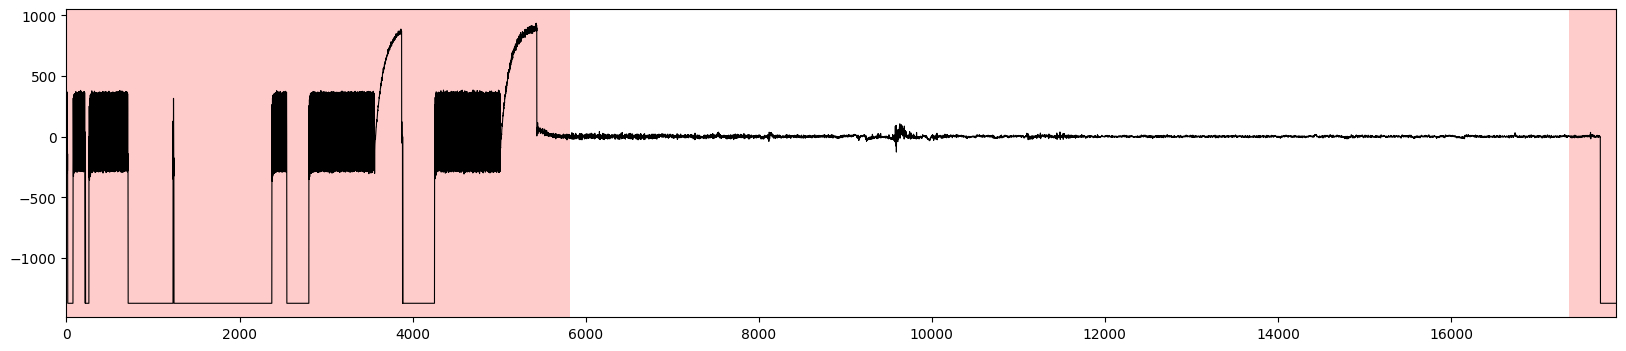

In [10]:
clipped_mask = clipped_per_channel_mask.any(axis=0)
bad_mask = clipped_mask | high_var_mask
print(bad_mask.shape)
plot_signal_with_bad_regions(sigs_se[chn], valid_mask=~bad_mask)

# Turn indices into intervals

In [57]:
def mask_to_time_intervals(valid_mask: np.ndarray, sfreq: float):
    """
    Convert a 1D boolean mask (True=valid, False=invalid) into time intervals.

    Intervals are half-open: [start_sec, end_sec) where end_sec is EXCLUSIVE.

    Returns
    -------
    valid_intervals_sec : list[tuple[float, float]]
    invalid_intervals_sec : list[tuple[float, float]]
    """
    m = np.asarray(valid_mask, dtype=bool)
    if m.size == 0:
        return [], []

    def _runs_to_intervals(mask_bool: np.ndarray) -> list[tuple[float, float]]:
        # pad with False so edges are detected as transitions
        padded = np.r_[False, mask_bool, False]
        changes = np.diff(padded.astype(np.int8))

        starts_idx = np.where(changes == 1)[0]  # False -> True
        ends_idx = np.where(changes == -1)[0]  # True -> False (exclusive)

        print(starts_idx.shape)
        zipped = np.column_stack((starts_idx, ends_idx))
        return zipped / sfreq

    valid_intervals = _runs_to_intervals(m)
    invalid_intervals = _runs_to_intervals(~m)
    return valid_intervals, invalid_intervals

In [94]:
valid_ivs, invalid_ivs = (mask_to_time_intervals(~bad_mask, SAMPLING_FREQUENCY_HZ))
print('valid:')
print(valid_ivs)
print('invalid:')
print(invalid_ivs)

(1,)
(2,)
valid:
[[28.12138502 83.89079614]]
invalid:
[[ 0.         28.12138502]
 [83.89079614 86.52808164]]


# Approach 2: Filtering by minimum values and high variance around them

In [63]:
min_iv_dist = int(15 * SAMPLING_FREQUENCY_HZ)
print(f"{min_iv_dist=}")

clipped_mask.shape

min_iv_dist=3105


(17914,)

In [95]:
# Turn it into intervals (mask2intervals)
def mask2intervals(mask_bool: np.ndarray):
    padded = np.r_[False, mask_bool, False]
    changes = np.diff(padded.astype(np.int8))

    starts_idx = np.where(changes == 1)[0]  # False -> True
    ends_idx = np.where(changes == -1)[0]  # True -> False (exclusive)
    zipped = np.column_stack((starts_idx, ends_idx))
    return zipped


clipped_ivs_raw = mask2intervals(clipped_mask)
# Prepend the start of file as interval
if clipped_ivs_raw[0][0] != 0:
    clipped_ivs_raw = np.vstack((np.array([0, 0]), clipped_ivs_raw))

print(clipped_ivs_raw)

[[    0     0]
 [   14    76]
 [  216   218]
 [  220   260]
 [  712  1232]
 [ 1242  2374]
 [ 2546  2802]
 [ 3884  3885]
 [ 3886  4254]
 [17727 17914]]


In [96]:
from typing import Tuple, List
from typing import Iterable

# make sure there's at least a certain distance between the intervals

Interval = Tuple[int, int]


def merge_intervals_with_gap(intervals: Iterable[tuple], min_gap: int):
    """
    Merge intervals if the gap between consecutive intervals is <= min_gap.
    Intervals are assumed half-open [start, end) (end is exclusive).
    """
    merged = []
    cur_s, cur_e = intervals[0]

    for s, e in intervals[1:]:
        if s - cur_e <= min_gap:  # gap small -> merge
            cur_e = max(cur_e, e)
        else:
            merged.append(np.array([cur_s, cur_e]))
            cur_s, cur_e = s, e

    merged.append((cur_s, cur_e))
    return np.array(merged)

merged_ivs:
[[    0  4254]
 [17727 17914]]
starting seeds:
[ 4254 17914]
0 4254
17727 17914


<Axes: >

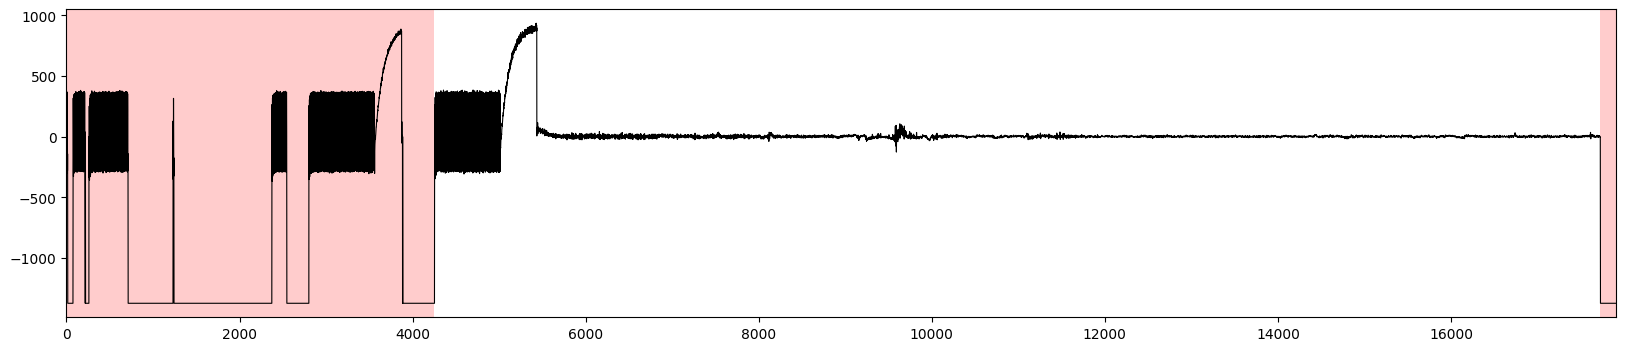

In [98]:
merged_ivs = merge_intervals_with_gap(clipped_ivs_raw, min_iv_dist)
print('merged_ivs:')
print(merged_ivs)
print('starting seeds:')
print(merged_ivs[:, 1])

plot_signal_with_bad_regions(sigs_se[chn], valid_intervals=merged_ivs)

In [106]:
# Check the signal after the clipped intervals
seed0 = merged_ivs[0, 1]
lookahead = round(20 * SAMPLING_FREQUENCY_HZ)
sig_to_check = sigs_se[chn, seed0: seed0 +lookahead]
print(sig_to_check.shape)


(4141,)


In [13]:
import numpy as np


def rolling_mean(x: np.ndarray, win: int) -> np.ndarray:
    if win <= 1:
        return x.astype(float)
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")


def rolling_var(x: np.ndarray, win: int) -> np.ndarray:
    m = rolling_mean(x, win)
    m2 = rolling_mean(x * x, win)
    v = m2 - m * m
    return np.maximum(v, 0.0)


def detect_artifacts_seed_and_grow(
        x: np.ndarray,
        sfreq: float,
        physical_min: float,
        atol: float = 0.1,
        lookahead_sec: float = 20.0,
        win_sec: float = 2.0,
        stable_hold_sec: float = 2.0,
        thr_hf: float = 1_000.0,  # tune
        thr_var: float = 20_000.0,  # tune
        thr_slope: float = 5.0,  # tune (units/sec-ish)
):
    n = x.size
    win = max(1, int(round(win_sec * sfreq)))
    hold = max(1, int(round(stable_hold_sec * sfreq)))
    lookahead = max(1, int(round(lookahead_sec * sfreq)))

    # --- seed: at physical min ---
    at_min = np.isclose(x, physical_min, atol=atol)
    seed_runs = [(s, e) for (s, e) in find_runs(at_min)]

    # --- features ---
    dx = np.diff(x, prepend=x[0])
    hf_energy = rolling_mean(dx * dx, win)  # "rapid oscillation"
    var = rolling_var(x, win)
    mean = rolling_mean(x, win)
    slope = np.abs(np.diff(mean, prepend=mean[0])) * sfreq  # approx derivative

    persists = (at_min | (hf_energy > thr_hf) | (var > thr_var) | (slope > thr_slope))

    # --- grow artifacts from seeds ---
    artifacts = []
    for s0, e0 in seed_runs:
        start = s0
        t = e0

        # force at least a lookahead region to be considered (optional)
        t = min(n, max(t, e0 + lookahead))

        # now grow until stable for hold samples
        stable_count = 0
        while t < n:
            if persists[t]:
                stable_count = 0
            else:
                stable_count += 1
                if stable_count >= hold:
                    # end at the first sample of the stable streak
                    end = t - hold + 1
                    artifacts.append((start, end))
                    break
            t += 1
        else:
            artifacts.append((start, n))

    # merge overlaps
    artifacts.sort()
    merged = []
    for s, e in artifacts:
        if not merged or s > merged[-1][1]:
            merged.append([s, e])
        else:
            merged[-1][1] = max(merged[-1][1], e)
    return [tuple(iv) for iv in merged]